In [11]:
%load_ext autoreload
%autoreload 2
import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')
from ult import *
from irc_gym.irc.model import FuncBeliefModel
from stable_baselines3 import PPO
from auditoryforage.AF_env import AuditoryForagingReward2 as AFR2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
modelname = 'vary p1 v5'
iepoch=11

plist = [np.array([.5, .8]),np.array([.51, .8]),np.array([.52, .8]),np.array([.53, .8])]
epoch_size = 33333
n_epoch = 66
n_seed = 1
seed = 0
no_episodes = 6666  # for eval plot during training
plot_no_episodes = 555
vmin, vmax = 10, 10000
food_reward_list = np.linspace(vmin, vmax, 5)
attcost = -1.6
facost = -50
node=25
env_param = [0, None, attcost, .25, facost, 0, 0]
np.random.seed(seed)
minlen, maxlen=50,100

In [13]:
# eval collection -------------------
results = []
for ip, p1p2 in enumerate(plist):
    thismodel = f'seed{seed}_{modelname}_p{ip}_ep{iepoch}'
    task = AFR2(spec={'agent':
                      {'lick_cost': env_param[0],
                       'food_reward': env_param[1],
                       'attention_cost_coeff': env_param[2],
                       'attention_cost_temp': env_param[3],
                       'penalty_cost': env_param[4],
                       'iti_cost': env_param[5],
                       'time_in_game_reward': env_param[6]},
                      'experiment': {'no_signal_nodes': node}})
    task.food_reward_list = food_reward_list
    taskbelief = FuncBeliefModel(env=task, rng=1)
    task.obs_certainity_possible = p1p2
    model = PPO.load(f'ycstore/{thismodel}', env=taskbelief)

    def eval_wrapper(a):
        episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
                                  num_steps=100000, deterministic=True)
        return episode

    with multiprocess.Pool(processes=8) as pool:
        # for p. vary r.
        all_episode_data = pool.map(eval_wrapper, range(no_episodes))

    for episode in all_episode_data:
        # process
        episode['ip'] = ip
        episode['at_times'] = np.where(
            np.array([elt[1] for elt in episode['actions']]) == 1)[0].astype('int')
        episode['at_seq'] = [float(elt[1])
                             for elt in episode['actions']]
        if episode['actions'][-1][0] == 1:
            episode['licktime'] = int(len(episode['states']))
        else:
            episode['lick_licktimetime'] = -1
        episode['trial_len'] = len(episode['actions'])

        results.append(episode)

df = pd.DataFrame(results)

/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


/Users/yc/repo/auditory-foraging-IRC/ult.py:1051: RuntimeWarning: invalid value encountered in divide
  return (np_array - mean**2)/variance
/Users/yc/repo/auditory-foraging-IRC/ult.py:1051: RuntimeWarning: invalid value encountered in divide
  return (np_array - mean**2)/variance
/Users/yc/repo/auditory-foraging-IRC/ult.py:1051: RuntimeWarning: invalid value encountered in divide
  return (np_array - mean**2)/variance
/Users/yc/repo/auditory-foraging-IRC/ult.py:1051: RuntimeWarning: invalid value encountered in divide
  return (np_array - mean**2)/variance


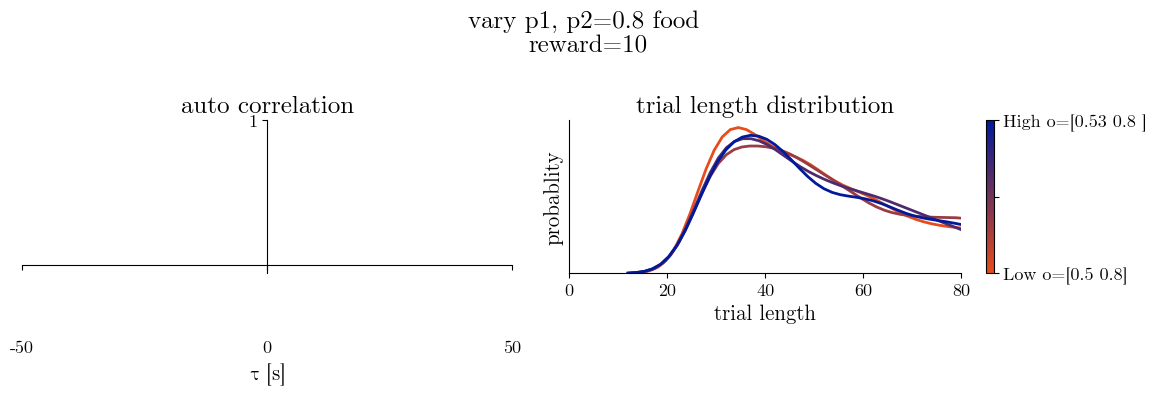

/Users/yc/repo/auditory-foraging-IRC/ult.py:1051: RuntimeWarning: invalid value encountered in divide
  return (np_array - mean**2)/variance


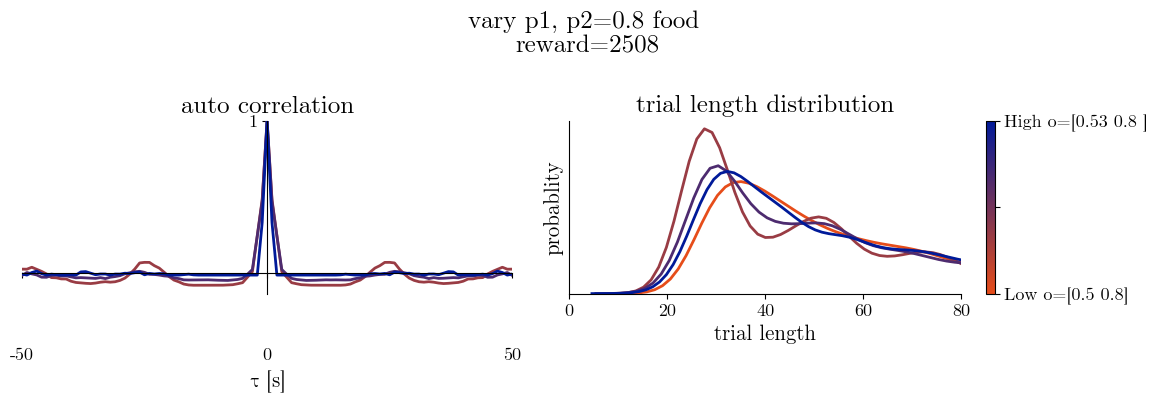

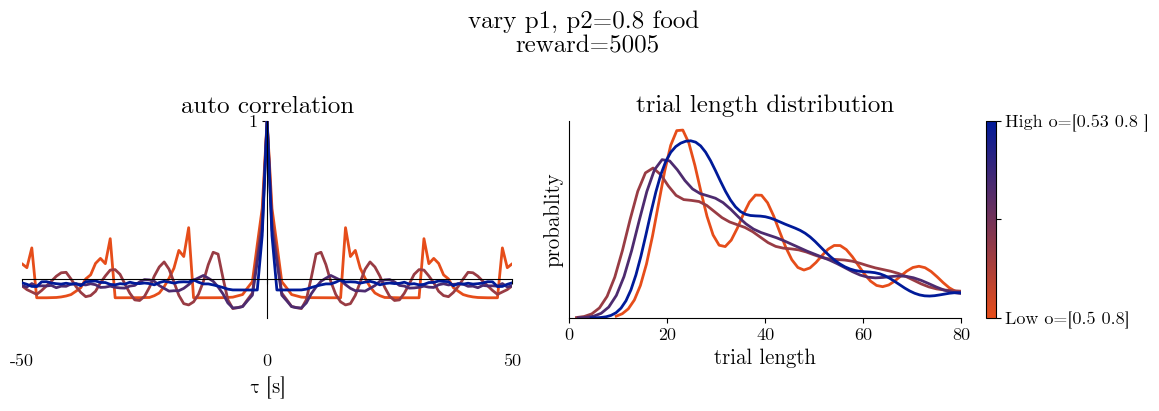

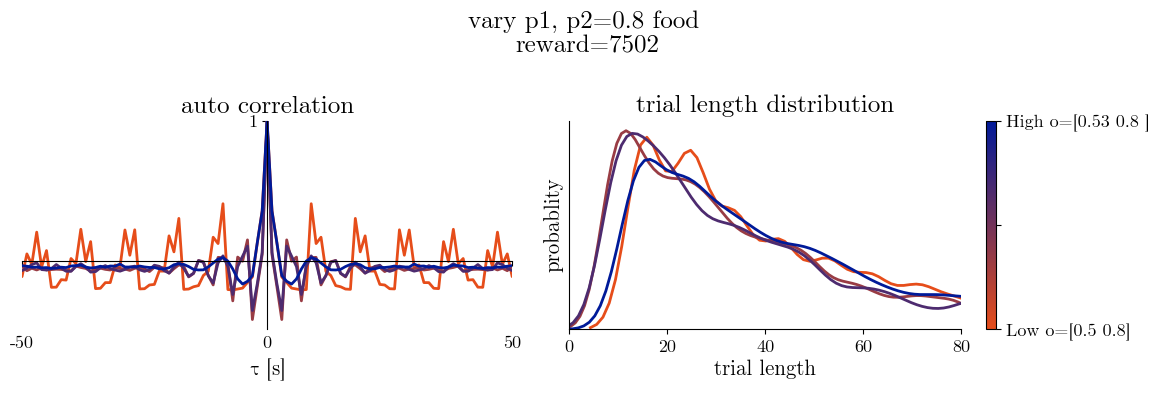

/Users/yc/repo/auditory-foraging-IRC/ult.py:1051: RuntimeWarning: invalid value encountered in divide
  return (np_array - mean**2)/variance
/Users/yc/repo/auditory-foraging-IRC/ult.py:1051: RuntimeWarning: invalid value encountered in divide
  return (np_array - mean**2)/variance


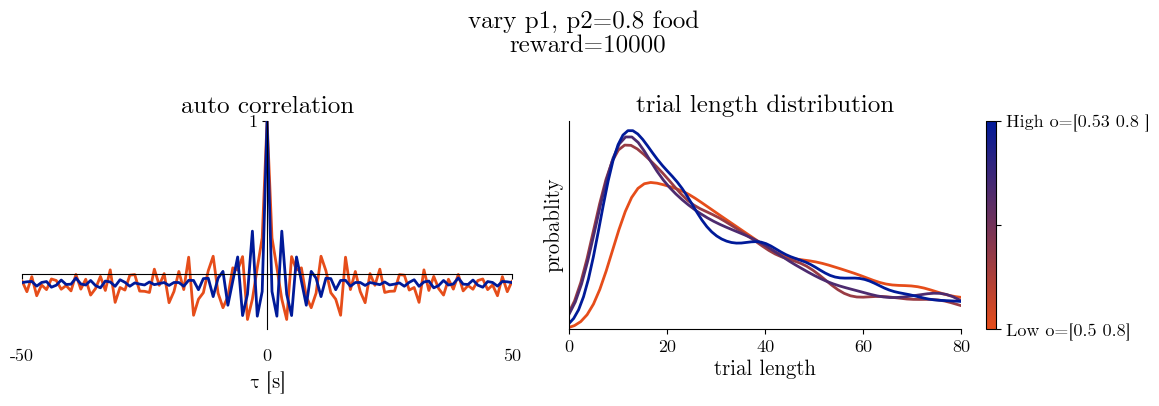

In [ ]:
# new eval ploting --------------------
start_rgb = (0.9, 0.3, 0.1) # low reward
end_rgb = (0.0, 0.1, 0.6) # high reward
pcmap = LinearSegmentedColormap.from_list('pcmap', [start_rgb, end_rgb])
pcmap(np.linspace(0, 1, len(plist)))

for food_reward_idx in range(len(food_reward_list)):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    for ip, p1p2 in enumerate(plist):
        subdf=df[(df.trial_food_reward_idx==food_reward_idx) & (df.ip==ip)]
        if len(subdf)==0: 
            print(food_reward_idx, ip, 'skipped')
            continue
        att_seq_list = np.array(subdf.at_seq)
        # print(len(subdf), food_reward_idx, ip)
        autocorr, total_counts = empirical_autocorrelation_new(
            att_seq_list, min_no_samples=1111)
        # print(att_seq_list)
        xs = np.arange(0, len(autocorr), 1)
        xs = xs-len(xs)//2
        ax1.plot(xs, autocorr,
                 label=f'p:{p1p2}', color=pcmap(np.linspace(0, 1, len(plist)))[ip])
        # trial len dist
        sns.kdeplot([len(a) for a in att_seq_list],
                    fill=False, bw_adjust=0.5, ax=ax2, color=pcmap(np.linspace(0, 1, len(plist)))[ip])
    ax1.set_xlabel(r'$\tau$ [s]')
    ax1.set_title('auto correlation')
    ax1.set_xlim(-50, 50)
    ax1.set_ylim(None, 1)
    ax1.set_xticks([-50, 0, 50])
    # ax1.set_yscale('log')
    ax1.set_yticks([1])
    ax1.spines['left'].set_position('zero')
    ax1.spines['bottom'].set_position('zero')
    ax1.tick_params(axis='x', pad=50)

    ax2.set_xlabel('trial length')
    ax2.set_ylabel('probablity')
    ax2.set_yticks([])
    ax2.set_xlim(0, 80)
    ax2.set_title('trial length distribution')

    color_bar = plt.colorbar(plt.cm.ScalarMappable(cmap=pcmap), ax=ax2)
    ticks = [0, 0.5, 1]
    tick_labels = [f'Low o={plist[0]}', '', f'High o={plist[-1]}']
    color_bar.set_ticks(ticks)
    color_bar.set_ticklabels(tick_labels)



    fig.suptitle(
        f'vary p1, p2={p1p2[1]} food \nreward={food_reward_list[food_reward_idx]:.0f}')
    fig.tight_layout()
    plt.show()

/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_2398/3604472188.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  rasterfig.show()


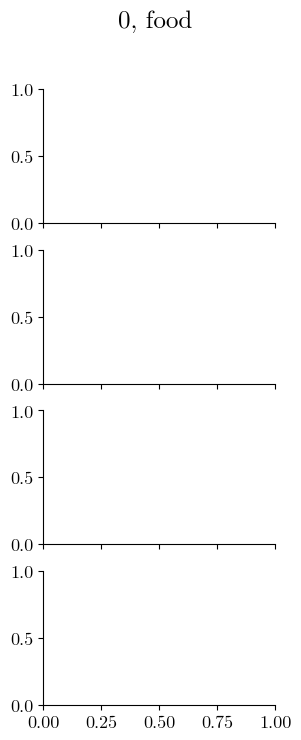

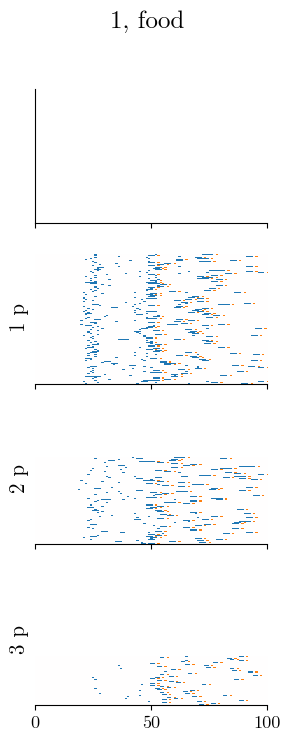

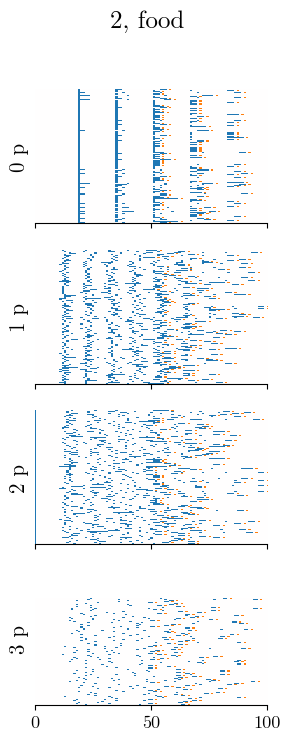

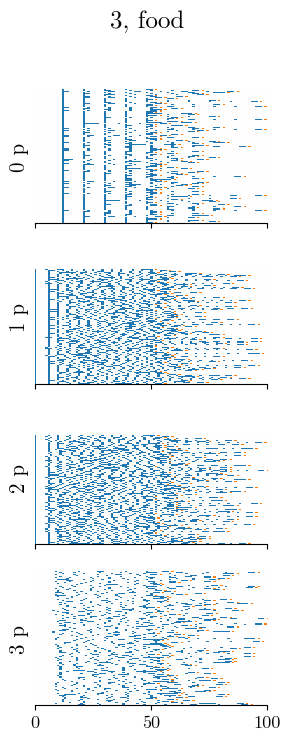

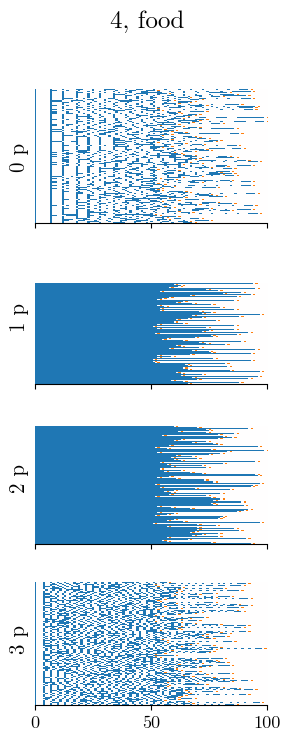

In [ ]:
# new eval ploting --------------------
for food_reward_idx in range(len(food_reward_list)):
    rasterfig, axs = plt.subplots(len(plist), 1, figsize=(
        3, len(plist)*2,), sharex=True, sharey=True)
    for ip, p1p2 in enumerate(plist):
        subdf=df[(df.trial_food_reward_idx==food_reward_idx) & (df.ip==ip)]

        # df=df[df['at_times'].apply(len) > 0]
        subdf=subdf[subdf.licktime!=-1]
        # df.licktime=df.licktime.astype('int')
        subdf=subdf[~subdf.licktime.isna()]

        if len(subdf)==0: continue
        trial_len = np.array(subdf.trial_len)
        valid_ind = np.where((minlen < trial_len) & (trial_len < maxlen))[0]
        grid = np.zeros((len(valid_ind), max(trial_len)+2))
        # print(food_reward_idx,ip, grid.shape)
        sortind = np.argsort([trial_len[i] for i in valid_ind])

        # att
        plot_data = np.array(subdf.at_times)[valid_ind]
        for i, arr in enumerate(plot_data):
            grid[i, arr] = -1
        # lick
        plot_data = np.array(subdf.licktime)[valid_ind]
        for i, arr in enumerate(plot_data):
            if arr:
                grid[i, int(arr)] = 1


        c = axs[ip].imshow(grid, cmap=attnlickcmap, vmin=-1, vmax=1,
                           aspect='auto', interpolation='none')

        axs[ip].set_xticks([0, 50, 100])
        axs[ip].set_xlim(0, 100)
        axs[ip].set_ylim(0, 300)
        axs[ip].set_yticks([])
        axs[ip].spines['left'].set_visible(False)
        axs[ip].set_ylabel(f'{ip} p')
    rasterfig.suptitle(f'{food_reward_idx}, food')
    rasterfig.show()

/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_2398/3805118278.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot([len(a) for a in subdf.at_times],  label=f'food reward={food_reward_list[food_reward_idx]:.0f}, p={p1p2}', bw_adjust=2, common_norm=False, color=pcmap(
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_2398/3805118278.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot([len(a) for a in subdf.at_times],  label=f'food reward={food_reward_list[food_reward_idx]:.0f}, p={p1p2}', bw_adjust=2, common_norm=False, color=pcmap(
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_2398/3805118278.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot([len(a) for a in subdf.at_times],  label=f'food reward={food_re

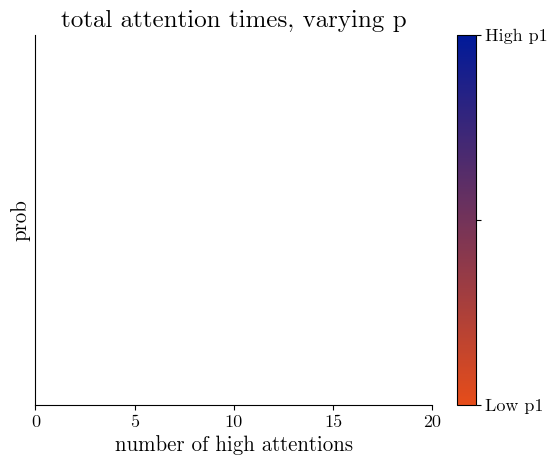

/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_2398/3805118278.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot([len(a) for a in subdf.at_times],  label=f'food reward={food_reward_list[food_reward_idx]:.0f}, p={p1p2}', bw_adjust=2, common_norm=False, color=pcmap(
webf NOT subset; don't know how to subset; dropped


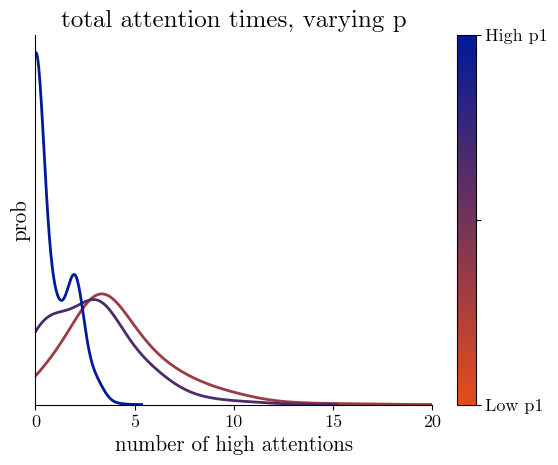

webf NOT subset; don't know how to subset; dropped


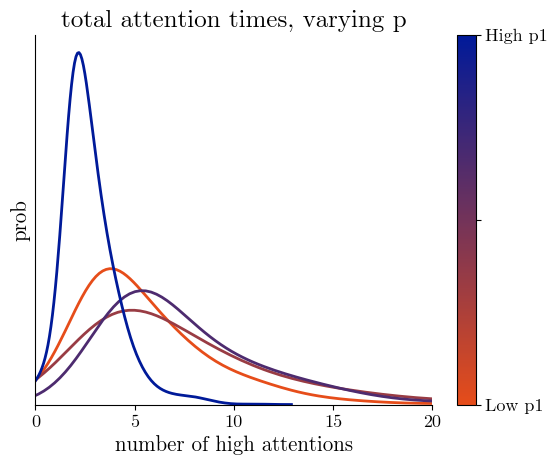

webf NOT subset; don't know how to subset; dropped


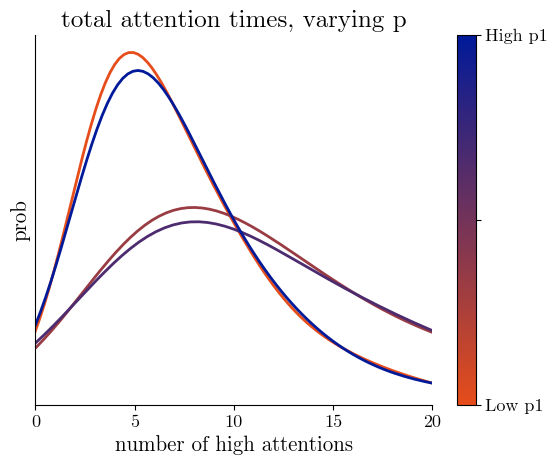

webf NOT subset; don't know how to subset; dropped


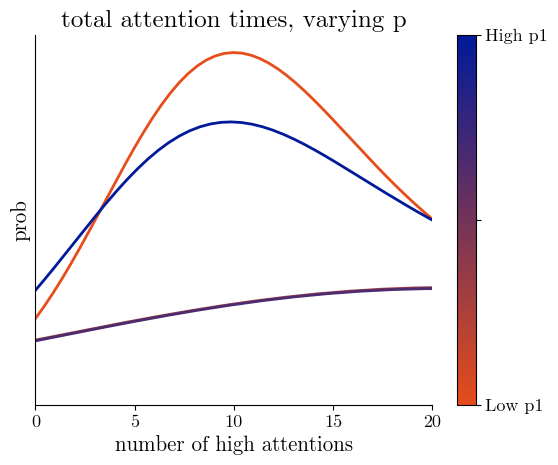

In [ ]:


for food_reward_idx in np.arange(len(food_reward_list)):
    fig= plt.figure()
    for ip, p1p2 in enumerate(plist):
        subdf=df[(df.trial_food_reward_idx==food_reward_idx) &(df.ip==ip)]
        sns.kdeplot([len(a) for a in subdf.at_times],  label=f'food reward={food_reward_list[food_reward_idx]:.0f}, p={p1p2}', bw_adjust=2, common_norm=False, color=pcmap(
            np.linspace(0, 1, len(plist)))[ip])


    color_bar = plt.colorbar(plt.cm.ScalarMappable(cmap=pcmap), ax=plt.gca())
    ticks = [0, 0.5, 1]
    tick_labels = ['Low p1', '', 'High p1']
    color_bar.set_ticks(ticks)
    color_bar.set_ticklabels(tick_labels)


    plt.xlabel('number of high attentions')
    plt.ylabel('prob')
    plt.title(f'total attention times, varying p')
    # plt.ylim(0,1500)
    # plt.legend()

    centerax(plt.gca())
    plt.yticks([])
    plt.xlim(0, 20)
    # plt.xticks([0, 15])
    quicksave('total att time', 'plot sigmoid', fig=fig)
    plt.show()
